# Ensemble Methods
### (adapted from from Professsor Kyle Whynott's CPSC 483 course material)

## 0. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
# Notice HistGradientBoostingClassifier is used for the large dataset (even XGBoost is a good candidate here)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Import Imbalanced Learn: Briefly Mentioned Before to Retain Class Proportions and Undersample I will be using the Imblearn Library
# from imblearn.under_sampling import RandomUnderSampler
# from imblearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance
from sklearn.utils import resample
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint
import math
import joblib
import random

## 1. Framing the Problem

1. What is the **Business Objective** in Building this Machine Learning Model?
    - **Goal:** To Detect Fradualent Transactions while Minimizing False Negatives
  
2. How does the company expect to use and benefit from this model?
    - Suppose in this seanario the company is a financial institution such as a Bank or Federal Credit Union, they would use the model to prematurely detect a fradualent transaction as-it is attempted to be processed on the consumer side (when a 'customer' is making a purchase in-store). The actual cardholder would then file a claim in a attempt to be reimbursed which most financial institutions usually do, but this results in **12.5 billion dollars** from credit card fraud in the U.S. in 2025, and **117 million dollars** from debit card fraud in 2025, [Merchant Cost Consulting](https://merchantcostconsulting.com/lower-credit-card-processing-fees/credit-card-fraud-statistics/). If the model is implemented by SWEs in these instiutions pontentially it can save billions of dollars per year.

3. Performance Metrics Used
    - Primarily **Percision-Recall AUC**, which is more important than **accuracy** for rare-event detection.
  
4. Assumptions Made
    1. Historical Data is Representative
       - The fradulent transaction data roughly reflects future fraudulent transaction data
    2. Labels are Mostly Correct
       - As we find later the labels need to be converted from float to int, but this is a very minor issue
    3. Each Row is a Independent Observation of a Potentially Fraudulent Transaction

## 2. Import the Data

In [ ]:
data = pd.read_csv("../dataset/card_transdata.csv", sep=",")

## 3. Exploratory Data Analysis

In [ ]:
display(data.head())
display(data.info())
display(data.describe(include="all"))

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


None

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
for i, x in enumerate(data):
    display(data[x].value_counts(normalize=True))

distance_from_home
57.877857    0.000001
10.829943    0.000001
5.091079     0.000001
2.247564     0.000001
44.190936    0.000001
               ...   
2.207101     0.000001
19.872726    0.000001
2.914857     0.000001
4.258729     0.000001
58.108125    0.000001
Name: proportion, Length: 1000000, dtype: float64

distance_from_last_transaction
0.311140    0.000001
0.175592    0.000001
0.805153    0.000001
5.600044    0.000001
0.566486    0.000001
              ...   
0.112651    0.000001
2.683904    0.000001
1.472687    0.000001
0.242023    0.000001
0.318110    0.000001
Name: proportion, Length: 1000000, dtype: float64

ratio_to_median_purchase_price
1.945940    0.000001
1.294219    0.000001
0.427715    0.000001
0.362663    0.000001
2.222767    0.000001
              ...   
1.626798    0.000001
2.778303    0.000001
0.218075    0.000001
0.475822    0.000001
0.386920    0.000001
Name: proportion, Length: 1000000, dtype: float64

repeat_retailer
1.0    0.881536
0.0    0.118464
Name: proportion, dtype: float64

used_chip
0.0    0.649601
1.0    0.350399
Name: proportion, dtype: float64

used_pin_number
0.0    0.899392
1.0    0.100608
Name: proportion, dtype: float64

online_order
1.0    0.650552
0.0    0.349448
Name: proportion, dtype: float64

fraud
0.0    0.912597
1.0    0.087403
Name: proportion, dtype: float64

## 4. Prepare  Data and Select Model(s) for Machine Learning

### Data Cleaning

#### Drop (or Fill) All NaN Values from Dataset (Clean the Data)

- DataFrame.fillna()
- DataFrame.drop()
- DataFrame.dropna()


See [Pandas Documentation - Data Frame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) for more methods and information on methods already used in class. (**Same link as above for Pandas**)

*Note: Sometimes it will be necessary depending on the dataset to also use __Numpy's methods__ documentation on this can be found [here](https://numpy.org/doc/stable/index.html) ( i.e. np.unique() )*

In [ ]:
data.dropna(axis=0, how="all", inplace=True)
data.dropna(axis=1, how="all", inplace=True)

- Convert all __floats__ for true or false (binary) columns to __ints__

In [ ]:
data["repeat_retailer"] = data["repeat_retailer"].astype(int)
data["used_chip"] = data["used_chip"].astype(int)
data["used_pin_number"] = data["used_pin_number"].astype(int)
data['online_order'] = data['online_order'].astype(int)
data['fraud'] = data['fraud'].astype(int)

**Hint**: In the end-end ML project example there's one column that gets converted to int, now we need to do it with all columns that represent binary values (1's and 0's)

### Balance Out the Classes (To prevent Class Imbalance and Reduce the Amount of Samples)


In [ ]:
# Seperate the majority and minority classes
majority_class = data[data["fraud"] == 0]
minority_class = data[data["fraud"] == 1]
len(majority_class)
len(minority_class)
ratio = len(minority_class) / len(majority_class)
print(f"Ratio: {ratio}")
# Downsample the majority class to match the minority class
downsampled_majority_class = resample(majority_class,
                                      replace=False,
                                      n_samples=10000,
                                      random_state=42)

downsampled_minority_class = resample(minority_class,
                                     replace=False,
                                     n_samples=round(10000 * ratio),
                                     random_state=42)

'''
Note: This is how problems with real-world class imblance should be downsampled, the `ratio` variable preseves the original class imbalance
while down-sampling the class. Also, whether to preseve the class imbalance or not is solely dependent on the real-world implication.
In fraud detection, even though there are a lot of cases, it is still relativly rare as compared to non-fradualent transactions so in this case
it is more statistically siginificant to preserve the class imbalance.
'''

# Combine the two dataframes together
data = pd.concat([downsampled_majority_class, downsampled_minority_class])

Ratio: 0.09577392868922427


In [ ]:
len(downsampled_majority_class)

10000

In [ ]:
len(downsampled_minority_class)

958

### Perform Stratified Sampling and Reduce the Amount of Data to Prevent Overfitting

- Checkout [Scikit Learn's Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html) to see how to create a StratifiedShuffleSplit
- Or... [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) with stratified sampling

In [ ]:
data_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in data_split.split(data, data['fraud']):
    train_set = data.iloc[train_idx]
    test_set = data.iloc[test_idx]

X_train = train_set.drop('fraud', axis=1)
y_train = train_set['fraud']

X_test = test_set.drop('fraud', axis=1)
y_test = test_set['fraud']

### Build the Data Pipeline

In [ ]:
# Build the Data Pipeline
features = X_train.select_dtypes(include=["int64", "float64"]).columns
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessing = ColumnTransformer([
    ("num", pipeline, features),
])

### Create Baseline Model

In [ ]:
baseline = Pipeline([
    ("prep", preprocessing),
    ("model", DummyClassifier(strategy="stratified"))
])

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
baseline_scores = cross_val_score(
    baseline,
    X_train,
    y_train,
    scoring="average_precision",
    cv=skf
)

baseline_scores.mean()

np.float64(0.08692880204003454)

## 5. Select and Train the Model(s)

### Voting Classifier

In [ ]:
voting_fraud_clf = make_pipeline(preprocessing,
    VotingClassifier(
        estimators= [
            ('rf', RandomForestClassifier(class_weight="balanced", max_depth=6, max_features=2, max_leaf_nodes=5, min_samples_leaf=1, min_samples_split=5, n_estimators=268, random_state=42)),
            ('svc', SVC(C=4.9868654247546385, break_ties=True, coef0=1.3260331922696553, gamma='auto', kernel='rbf', probability=True, random_state=42)),
            ('hgb', HistGradientBoostingClassifier(early_stopping='auto', interaction_cst='pairwise', l2_regularization=0.6234588024048923, learning_rate=0.7934293594590593, max_depth=19, max_iter=294, max_leaf_nodes=42, min_samples_leaf=57, warm_start=True, n_iter_no_change=10, random_state=42))
        ],
        voting="soft"
    )
)

In [ ]:
voting_fraud_clf.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('votingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

### Run Cross-Validation to Get the Score of the Intial ML Model

In [ ]:
vfc = cross_val_score(
    voting_fraud_clf,
    X_train,
    y_train,
    scoring="average_precision",
    cv=skf
)

vfc.mean()

np.float64(0.9986284283226604)

### Stacking Classifier

In [ ]:
stacking_fraud_clf = make_pipeline(preprocessing,
    StackingClassifier(
        estimators= [
            ('rf', RandomForestClassifier(class_weight="balanced", max_depth=6, max_features=2, max_leaf_nodes=5, min_samples_leaf=1, min_samples_split=5, n_estimators=268, random_state=42)),
            ('svc', SVC(C=4.9868654247546385, break_ties=True, coef0=1.3260331922696553, gamma='auto', kernel='rbf', probability=True, random_state=42)),
            ('hgb',  HistGradientBoostingClassifier(early_stopping='auto', interaction_cst='pairwise', l2_regularization=0.6234588024048923, learning_rate=0.7934293594590593, max_depth=19, max_iter=294, max_leaf_nodes=42, min_samples_leaf=57, warm_start=True, n_iter_no_change=10, random_state=42))
        ],
        final_estimator=LogisticRegression(class_weight="balanced", random_state=64),
        cv=3
    )
)

# number of trees in random forest: n_estimators=268 (runs parallelly)
#  number of trees in hist gradient boosting: HistGradientBoostingClassifier: max_iter=294 (runs sequentially)

In [ ]:
stacking_fraud_clf.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('stackingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [ ]:
sfc = cross_val_score(
    stacking_fraud_clf,
    X_train,
    y_train,
    scoring="average_precision",
    cv=skf
)

sfc.mean()

np.float64(0.9986568686417274)

## 6. Fine Tune the Model

## Use Grid Search (or RandomSearch) CV For Hyper-Parameter Tuning

In [ ]:
'''
I am mainly tuning the Voting and Stacking Classifiers themselves, to save time. Ordinarily you would want to train all of them (including the ones within).

For example:
param_grid = {
    # wrapper-level
    "votingclassifier__weights": [[1,1,1], [2,1,1]],

    # inner models
    "votingclassifier__rf__n_estimators": [100, 200],
    "votingclassifier__rf__max_depth": [5, 10],

    "votingclassifier__svm__C": [0.1, 1, 10],
    "votingclassifier__svm__kernel": ["linear", "rbf"],

    "votingclassifier__lr__C": [0.1, 1, 10]
}
if the models were named like
VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('svm', svm_model),
        ('lr', lr_model)
    ]
)

'''
param_grid = {
    "votingclassifier__weights": [
        [1,1,1],
        [1,2,1],
        [1,1,2],
        [2,1,1],
        [1,2,1],
        [3,2,1],
        [2,3,1],
        [1,2,3]
    ],
    "votingclassifier__voting": ["soft"]
}

# Initialize the GridSearchCV (or GridSearchCV if chosen) object
grid_search = GridSearchCV(voting_fraud_clf, param_grid, cv=skf, scoring='average_precision', n_jobs=-1, verbose=3)

# Fit the grid(random) search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score achieved during the random grid search
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'votingclassifier__voting': 'soft', 'votingclassifier__weights': [2, 1, 1]}
Best cross-validation score: 0.9989248381366268


In [ ]:
'''
I am mainly tuning the Voting and Stacking Classifiers themselves, to save time. Ordinarily you would want to train all of them (including the ones within).
'''
param_grid = {
    "stackingclassifier__final_estimator__C": [0.1, 1, 10],
    "stackingclassifier__final_estimator__class_weight": [None, "balanced"],
    "stackingclassifier__passthrough": [True, False],
}

# Initialize the RandomSearchCV (or GridSearchCV if chosen) object
grid_search = RandomizedSearchCV(stacking_fraud_clf, param_grid, cv=skf, scoring='average_precision', n_iter=10, n_jobs=-1, verbose=3, random_state=42)

# Fit the grid(random) search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score achieved during the random grid search
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'stackingclassifier__passthrough': True, 'stackingclassifier__final_estimator__class_weight': None, 'stackingclassifier__final_estimator__C': 10}
Best cross-validation score: 0.9990340907246097


### Make Finalized Classifier with Newly Hypertuned Parameters and Refined Feature Selection

In [ ]:
voting_fraud_clf = make_pipeline(preprocessing,
    VotingClassifier(
        estimators= [
            ('rf', RandomForestClassifier(class_weight="balanced", max_depth=6, max_features=2, max_leaf_nodes=5, min_samples_leaf=1, min_samples_split=5, n_estimators=268, random_state=42)),
            ('svc', SVC(C=4.9868654247546385, break_ties=True, coef0=1.3260331922696553, gamma='auto', kernel='rbf', probability=True, random_state=42)),
            ('hgb', HistGradientBoostingClassifier(early_stopping='auto', interaction_cst='pairwise', l2_regularization=0.6234588024048923, learning_rate=0.7934293594590593, max_depth=19, max_iter=294, max_leaf_nodes=42, min_samples_leaf=57, warm_start=True, n_iter_no_change=10, random_state=42))
        ],
        voting="soft",
        weights=[2,1,1]
    )
)
voting_fraud_clf.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('votingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [ ]:
stacking_fraud_clf = make_pipeline(preprocessing,
    StackingClassifier(
        estimators= [
            ('rf', RandomForestClassifier(class_weight="balanced", max_depth=6, max_features=2, max_leaf_nodes=5, min_samples_leaf=1, min_samples_split=5, n_estimators=268, random_state=42)),
            ('svc', SVC(C=4.9868654247546385, break_ties=True, coef0=1.3260331922696553, gamma='auto', kernel='rbf', probability=True, random_state=42)),
            ('hgb',  HistGradientBoostingClassifier(early_stopping='auto', interaction_cst='pairwise', l2_regularization=0.6234588024048923, learning_rate=0.7934293594590593, max_depth=19, max_iter=294, max_leaf_nodes=42, min_samples_leaf=57, warm_start=True, n_iter_no_change=10, random_state=42))
        ],
        final_estimator=LogisticRegression(class_weight=None, C=10, random_state=64),
        cv=3
    )
)
stacking_fraud_clf.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('stackingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### Evaluate the Final Model on the Test Set

In [ ]:
# Hard predictions
y_vote_test_pred = voting_fraud_clf.predict(X_test)
print(f"Vote Hard Predictions: {y_vote_test_pred}")
y_stack_test_pred = stacking_fraud_clf.predict(X_test)
print(f"Stack Hard Predictions: {y_stack_test_pred}")


# Probabilities (needed for ranking metrics)
y_vote_test_proba = voting_fraud_clf.predict_proba(X_test)[:, 1]
print(f"Vote Probabilities: {y_vote_test_proba}")
y_stack_test_proba = stacking_fraud_clf.predict_proba(X_test)[:, 1]
print(f"Stack Probabilities: {y_stack_test_proba}")

Vote Hard Predictions: [0 0 0 ... 0 0 0]
Stack Hard Predictions: [0 0 0 ... 0 0 0]
Vote Probabilities: [0.14097384 0.11106696 0.13162984 ... 0.25774906 0.13816999 0.2869691 ]
Stack Probabilities: [0.00031385 0.0001523  0.00025023 ... 0.00523139 0.00029305 0.0106148 ]


In [ ]:
conf_matrix = confusion_matrix(y_test, y_vote_test_pred)
class_report = classification_report(y_test, y_vote_test_pred, target_names=["Not Fraud", "Fraud"])
print('Voting Confusion Matrix:\n', conf_matrix)
print('Voting Classification Report:\n', class_report)

Voting Confusion Matrix:
 [[1998    2]
 [   0  192]]
Voting Classification Report:
               precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00      2000
       Fraud       0.99      1.00      0.99       192

    accuracy                           1.00      2192
   macro avg       0.99      1.00      1.00      2192
weighted avg       1.00      1.00      1.00      2192



### Plot the Final Confusion matrix

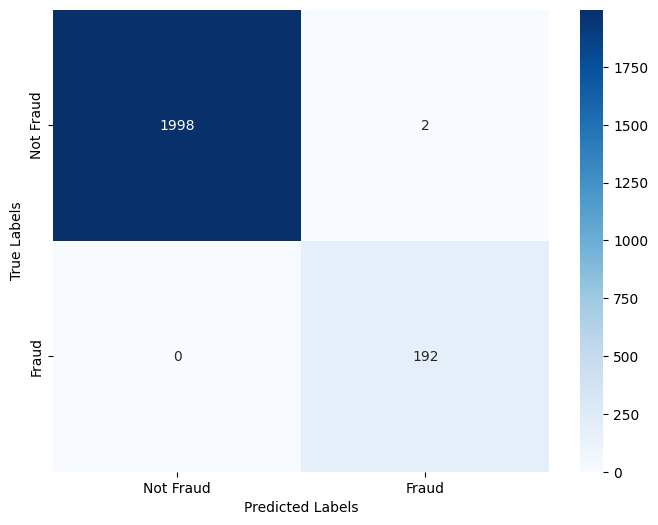

In [ ]:
class_names = ["Not Fraud", "Fraud"] # 0's and 1's
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='.0f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### Plot the Final Classification Report

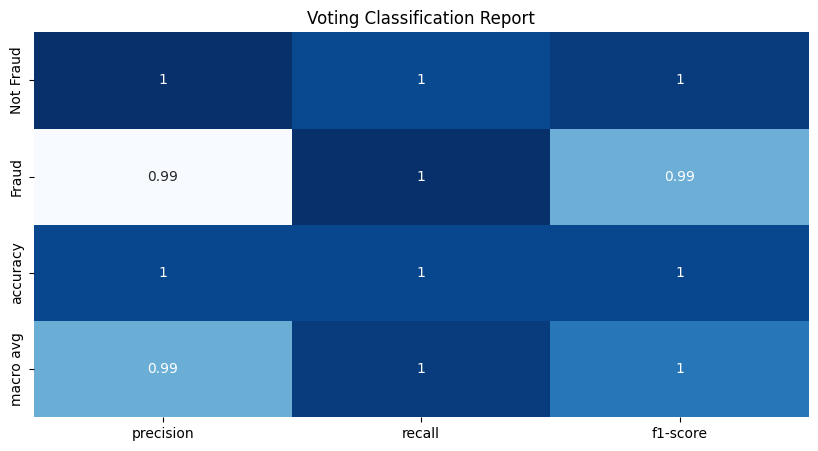

In [ ]:
class_report = classification_report(y_test, y_vote_test_pred, target_names=class_names, output_dict=True)
df_final_report = pd.DataFrame(class_report).transpose()
plt.figure(figsize=(10, 5))
sns.heatmap(df_final_report.iloc[:-1, :].drop(columns=['support']), annot=True, cmap='Blues', cbar=False)
plt.title('Voting Classification Report')
plt.show()

In [ ]:
conf_matrix = confusion_matrix(y_test, y_stack_test_pred)
class_report = classification_report(y_test, y_stack_test_pred, target_names=["Not Fraud", "Fraud"])
print('Stacking Confusion Matrix:\n', conf_matrix)
print('Stacking Classification Report:\n', class_report)

Stacking Confusion Matrix:
 [[1999    1]
 [   0  192]]
Stacking Classification Report:
               precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00      2000
       Fraud       0.99      1.00      0.99       192

    accuracy                           1.00      2192
   macro avg       0.99      1.00      1.00      2192
weighted avg       1.00      1.00      1.00      2192



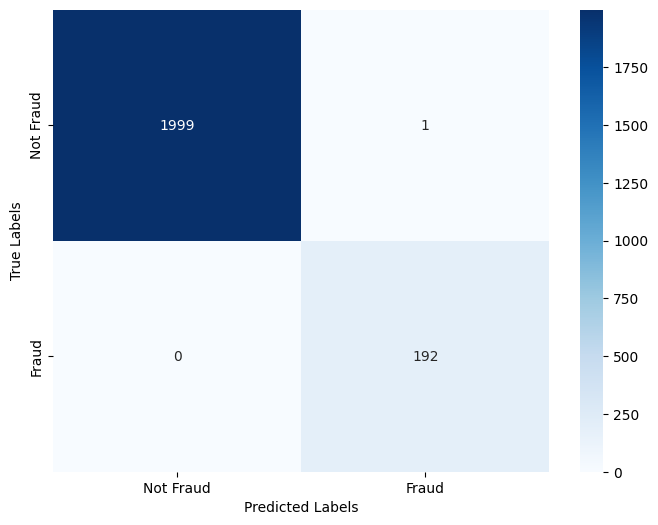

In [ ]:
class_names = ["Not Fraud", "Fraud"] # 0's and 1's
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='.0f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

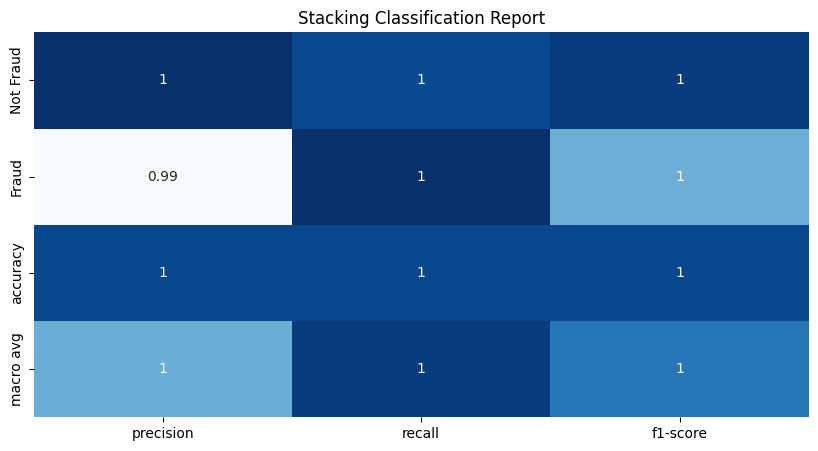

In [ ]:
class_report = classification_report(y_test, y_stack_test_pred, target_names=class_names, output_dict=True)
df_final_report = pd.DataFrame(class_report).transpose()
plt.figure(figsize=(10, 5))
sns.heatmap(df_final_report.iloc[:-1, :].drop(columns=['support']), annot=True, cmap='Blues', cbar=False)
plt.title('Stacking Classification Report')
plt.show()

### Plot and Get the Final Percision-Recall Score

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_vote_test_proba)
pr_auc = auc(recall, precision)

print(f"Precision–Recall AUC: {pr_auc:.4f}")

Precision–Recall AUC: 0.9996


In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_stack_test_proba)
pr_auc = auc(recall, precision)

print(f"Precision–Recall AUC: {pr_auc:.4f}")

Precision–Recall AUC: 0.9996


### Saving the Created Model for 'Live' Testing

In [ ]:
joblib.dump(voting_fraud_clf, "./models/fraud_vote.pkl")

['./models/fraud_vote.pkl']

In [ ]:
joblib.dump(stacking_fraud_clf, "./models/fraud_stack.pkl")

['./models/fraud_stack.pkl']

## Conclusions

The ensemble models (Voting and Stacking Classifiers) achieved extremely high performance on both cross-validation and test data, with near-perfect precision-recall AUC scores and very low misclassification rates. Importantly, there is no significant gap between training and test performance, indicating that the models are not clearly overfitting based on the available metrics.

However, the unusually high performance suggests that the dataset may be relatively easy to model or could potentially contain data leakage or patterns that are not representative of real-world scenarios. Therefore, while the ensemble methods perform very well, further validation on more realistic or unseen data is necessary.

In practice, simpler models may still be preferred for better interpretability and robustness, especially in real-world fraud detection tasks where data distributions can change over time.